
# Imágenes en Matplotlib

En este módulo, estudiaremos cómo podemos usar Matplotlib para visualizar
imágenes rasterizadas o mapas de bits y, también, cómo hacer algunas
manipulaciones básicas sobre las imágenes.

Empecemos importando los módulos que nos interesan de Matplotlib. En la primera,
importamos el módulo `Matplotlib.pyplot`, que incluye todas las funciones
que tienen que ver con la creación de gráficas. A este módulo, le vamos
a llamar `plt`. En la segunda línea, importamos el módulo `Matplotlib.image`
y le ponemos el nombre `mpimg`. Este módulo tiene todas las funciones que tienen
que ver con la carga y manipulación de imágenes rasterizadas.

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mp_img

Ahora, invocamos la función `imread` del módulo `mpimg` y le pasamos
como parámetro el nombre de un archivo que contenga una imagen. El resultado
lo vamos a almacenar en la variable `img`. Finalmente, invocamos la función
`imshow` del módulo `plt` y le pasamos como argumento la imagen que habíamos
guardado en la variable `img`. El resultado de esto es que se visualizará
la imagen que estaba almacenada en el archivo que le pasamos como parámetro
a la función `imread`. En este caso, se trata de una fotografía muy antigua
de León Tolstoi. El fotógrafo que la tomó fue de los primeros en experimentar
con fotografías en color, utilizando una técnica que nosotros vamos a recrear
usando Matplotlib.

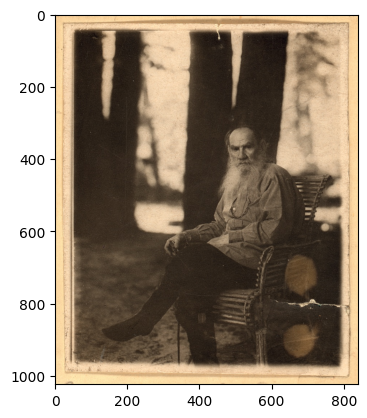

In [3]:
img = mp_img.imread("imagenes/tolstoi.jpg")
plt.imshow(img)

## Matrices de tuplas versus matrices de tres dimensiones

Lo primero que tenemos que saber es que Matplotlib no representa las imágenes
utilizando matrices de tuplas. En cambio, Matplotlib utiliza matrices de tres
dimensiones. Una dimensión se utiliza para el ancho, otra dimensión se utiliza
para el alto y la tercera dimensión se utiliza para separar entre el color rojo,
el color verde y el color azul. Al final, termina siendo una representación
totalmente equivalente a la que teníamos antes porque se puede guardar
exactamente la misma información, pero es importante que sepamos que hay esta
diferencia para que tengan sentido los fragmentos de código que vamos a estudiar
a continuación.

![Matrices de tuplas versus matrices de tres dimensiones](imagenes/matrices-de-tuplas-vs-matrices-3d.png)

Estudiemos ahora un poco la técnica que utilizó el fotógrafo Sergey Prokudin
para tomar fotografías en color en una época en la que únicamente existían
fotografías en blanco y negro. Lo que Prokudin notó fue que la luz se podía
descomponer en los tres colores que ya conocemos: rojo, verde y azul; y
aplicó estas ideas tomando fotografías en blanco y negro, pero con cámaras
a las cuales les había puesto filtros rojos, filtros verdes, y filtros azules.
De esta manera, obtuvo fotografías como las que vemos en la parte de abajo.
Son tres fotografías del mismo sujeto tomadas desde la misma posición,
pero una vez se tomaron con un filtro rojo, otra vez se tomaron con un filtro
verde, y otra vez se tomaron con un filtro azul. El resultado son tres
fotografías en blanco y negro bastante similares, pero con algunas diferencias
que dependen de las intensidades de cada uno de estos tres colores en cada uno
de los casos.

![Mezcla de imagenes a blanco y negro](imagenes/mezcla-de-imagenes-en-blanco-y-negro.png)

El paso siguiente fue mezclar los tres colores durante el proceso de revelado
de los tres negativos. Esa es, precisamente, la parte del proceso que,
a continuación, vamos a simular utilizando Matplotlib.

![Mezcla de imagenes a blanco y negro](imagenes/mezcla-de-imagenes-en-blanco-y-negro-2.png)

Empezamos importando las librerías que vamos a utilizar en nuestro programa.

En primer lugar, estamos importando `numpy` porque vamos a utilizar una función
de esta librería y después tenemos los `import` de `pyplot` y del módulo
de imágenes de Matplotlib. Además, estamos definiendo una nueva función
que llamaremos `combinar_imágenes`, la cual va a recibir los nombres de las tres
imágenes que corresponden a la imagen con el filtro rojo, la imagen con el
filtro verde, y la imagen con el filtro azul. Dentro de la función, lo primero
que hacemos es cargar las tres imágenes utilizando la función `imread()`
y guardar el resultado en tres variables `img_rojo`, `img_verde`, y `img_azul`.
Recordemos que cada una de estas tres imágenes va a ser una matriz de tres
dimensiones. Las dos primeras dimensiones sirven para indicar la fila
y la columna en la que se encuentra un pixel y la tercera dimensión sirve
para indicar el canal. Lo que hacemos entonces es utilizar el mecanismo de
"slicing" de los `ndarrays` de NumPy para convertir cada una de estas matrices
de tres dimensiones en matrices de dos dimensiones.

Para la primera matriz, que llamamos `componente_rojo`, únicamente nos quedamos
con los valores que estaban en el canal rojo, es decir, los valores en los
cuales, la tercera dimensión tenía valor cero; para el `componente_verde`,
nos quedamos únicamente con los píxeles en los cuales la tercera dimensión tenía
el valor uno y para, el `componente_azul`, nos quedamos únicamente con los valores
para los cuales la tercera dimensión tenía el valor dos.

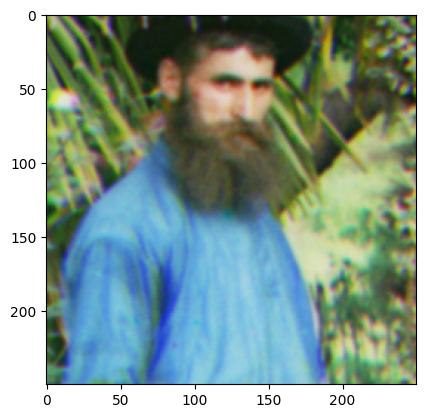

In [4]:
import numpy as np


def combinar_imagenes(rojo, verde, azul):
    img_rojo = mp_img.imread(rojo)
    img_verde = mp_img.imread(verde)
    img_azul = mp_img.imread(azul)

    componente_rojo = img_rojo[:, :, 0]
    componente_verde = img_verde[:, :, 1]
    componente_azul = img_azul[:, :, 2]

    rgb = np.dstack((componente_rojo, componente_verde, componente_azul))

    plt.imshow(rgb)
    return rgb


imagen_final = combinar_imagenes(
    "imagenes/alleia_hamerops_red.png",
    "imagenes/alleia_hamerops_green.png",
    "imagenes/alleia_hamerops_blue.png"
)

plt.imshow(imagen_final)

Es muy importante anotar que todo eso se puede hacer porque
la función `imread()` retorna una matriz de tres dimensiones, pero implementada
como `ndarray` en NumPy. Si la función nos hubiera retornado una matriz de tres
dimensiones nativa de Python, es decir, una lista de listas de listas,
no habríamos podido aplicar este mecanismo de "slicing" y habríamos tenido
que implementar la operación completamente nosotros.

Finalmente, utilizamos la función `dstack()` de NumPy. Esta función hace,
exactamente, lo mismo que se ve en el dibujo: toma tres matrices de dos
dimensiones y las apila para conseguir una matriz de tres dimensiones.
El resultado de aplicarle esta función a las tres fotografías tomadas con
filtros por Prokudin, es la imagen que vemos en la parte de abajo.

Es posible que los colores se vean un poco extraños, pero esto se debe
a que no tenemos registro de cuál era exactamente el tono de rojo, el tono
de verde, y el tono de azul que utilizó Prokudin en los filtros de su cámara.

Para terminar, recordemos que Matplotlib utiliza matrices de tres dimensiones
para representar las imágenes en lugar de las matrices de dos dimensiones
y tuplas que habíamos estado utilizando hasta ahora. Recordemos también que
las matrices en Matplotlib son `ndarrays` de NumPy, no son matrices nativas
de Python.

Finalmente, recomendamos utilizar siempre que puedan las operaciones de NumPy
sobre estos `ndarrays`. Son mucho más eficientes que cualquier algoritmo
que podría implementarse en Python, porque por debajo están implementados
en un lenguaje de programación diferente.